In [1]:
# 1. 手动编写逻辑回归类，能够实现二分类任务，要求实现如下的功能：
# 编写fit方法，能够训练模型，可以使用随机梯度下降优化。
# 在训练模型之后，模型具有coef与intercept属性，能够返回权重（ ）与偏置（ ）。
# 编写predict方法，能够对未知样本实现预测。
# 编写decision_function方法，用于计算 值（优势比对数值）。
# 编写predict_proba方法，用于计算样本属于每个类别的概率值。
# 不允许借助于scikit-learn中的逻辑回归类。
import numpy as np

class MyLogisticRegression:
    def __init__(self, lr=0.1, max_iter=1000, tol=1e-6, random_state=None):
        self.lr = lr
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

    # ======================
    # sigmoid 函数
    # ======================
    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    # ======================
    # 训练模型（SGD）
    # ======================
    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        n_samples, n_features = X.shape

        if self.random_state is not None:
            np.random.seed(self.random_state)

        # 初始化参数
        self.coef_ = np.zeros(n_features)
        self.intercept_ = 0.0

        prev_loss = np.inf

        for _ in range(self.max_iter):
            # 随机打乱样本顺序（SGD 的关键）
            indices = np.random.permutation(n_samples)

            for i in indices:
                xi = X[i]
                yi = y[i]

                # 线性部分
                z = np.dot(xi, self.coef_) + self.intercept_

                # 概率
                p = self._sigmoid(z)

                # 梯度
                grad_w = (p - yi) * xi
                grad_b = (p - yi)

                # 参数更新
                self.coef_ -= self.lr * grad_w
                self.intercept_ -= self.lr * grad_b

            # 计算整体 loss（用于早停）
            z_all = X @ self.coef_ + self.intercept_
            p_all = self._sigmoid(z_all)

            loss = -np.mean(
                y * np.log(p_all + 1e-15) +
                (1 - y) * np.log(1 - p_all + 1e-15)
            )

            if abs(prev_loss - loss) < self.tol:
                break

            prev_loss = loss

        return self

    # ======================
    # decision_function
    # ======================
    def decision_function(self, X):
        X = np.asarray(X)
        return X @ self.coef_ + self.intercept_

    # ======================
    # 预测概率
    # ======================
    def predict_proba(self, X):
        z = self.decision_function(X)
        p1 = self._sigmoid(z)
        p0 = 1 - p1
        return np.c_[p0, p1]

    # ======================
    # 预测类别
    # ======================
    def predict(self, X):
        proba = self.predict_proba(X)
        return (proba[:, 1] >= 0.5).astype(int)



In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 固定随机种子
np.random.seed(0)

# 正类
X_pos = np.random.randn(50, 2) + np.array([2, 2])
y_pos = np.ones(50)

# 负类
X_neg = np.random.randn(50, 2) + np.array([-2, -2])
y_neg = np.zeros(50)

# 合并数据
X = np.vstack([X_pos, X_neg])
y = np.hstack([y_pos, y_neg])
model = MyLogisticRegression(
    lr=0.1,
    max_iter=1000,
    tol=1e-6,
    random_state=42
)

model.fit(X, y)

print("coef_:", model.coef_)
print("intercept_:", model.intercept_)


coef_: [4.73638661 5.54343053]
intercept_: -1.3447469654484787


In [3]:
z = model.decision_function(X[:5])
print("decision_function:", z)


decision_function: [29.7883649  36.27280457 22.64289192 22.8758352  21.0021272 ]


In [4]:
proba = model.predict_proba(X[:5])
print("predict_proba:\n", proba)


predict_proba:
 [[1.15685239e-13 1.00000000e+00]
 [2.22044605e-16 1.00000000e+00]
 [1.46661794e-10 1.00000000e+00]
 [1.16185284e-10 1.00000000e+00]
 [7.56644747e-10 9.99999999e-01]]


In [5]:
y_pred = model.predict(X)

accuracy = np.mean(y_pred == y)
print("accuracy:", accuracy)


accuracy: 1.0


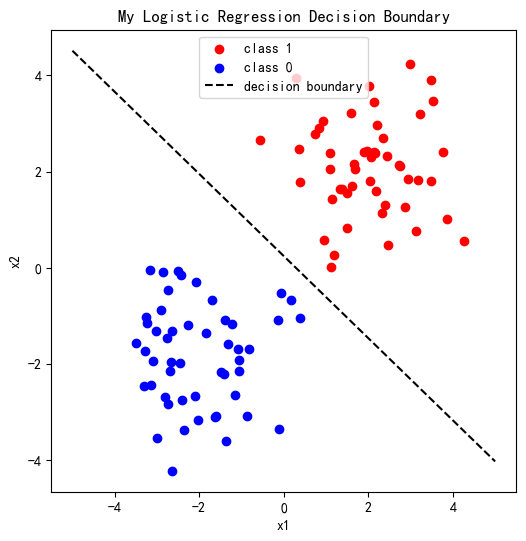

In [6]:
plt.figure(figsize=(6, 6))

# 原始数据
plt.scatter(X_pos[:, 0], X_pos[:, 1], c="red", label="class 1")
plt.scatter(X_neg[:, 0], X_neg[:, 1], c="blue", label="class 0")

# 决策边界：w1*x1 + w2*x2 + b = 0
w1, w2 = model.coef_
b = model.intercept_

x1 = np.linspace(-5, 5, 100)
x2 = -(w1 * x1 + b) / w2

plt.plot(x1, x2, "k--", label="decision boundary")

plt.legend()
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("My Logistic Regression Decision Boundary")
plt.show()


In [7]:
x_test = np.array([[0, 0], [3, 3], [-3, -3]])

print("decision_function:", model.decision_function(x_test))
print("predict_proba:\n", model.predict_proba(x_test))
print("predict:", model.predict(x_test))


decision_function: [ -1.34474697  29.49470445 -32.18419838]
predict_proba:
 [[7.93269494e-01 2.06730506e-01]
 [1.55209179e-13 1.00000000e+00]
 [1.00000000e+00 1.05336828e-14]]
predict: [0 1 0]


In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split


class MyLogisticRegression:
    def __init__(self, learning_rate=0.1, epochs=10):
        self.learning_rate = learning_rate
        self.epochs = epochs
        
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
        
    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        self.coef_ = np.random.random(X.shape[1])
        self.intercept_ = np.random.random()
        for _ in range(self.epochs):
            order = np.random.permutation(X.shape[0])
            for xi, yi in zip(X[order], y[order]):
                z = np.dot(xi, self.coef_) + self.intercept_
                p = self.sigmoid(z)
                self.coef_ += self.learning_rate * (yi - p) * xi
                self.intercept_ += self.learning_rate * (yi - p)
        return self
    
    def predict(self, X):
        z = self.decision_function(X)
        return np.where(z > 0, 1, 0)
    
    def decision_function(self, X):
        return np.dot(X, self.coef_) + self.intercept_
    
    def predict_proba(self, X):
        z = self.decision_function(X)
        p1 = self.sigmoid(z)
        p1 = p1.reshape(-1, 1)
        p0 = 1 - p1
        return np.concatenate([p0, p1], axis=1)
    
    
# 随机生成用于分类任务的数据集。
# n_samples：样本数量。
# n_features：特征数量。
# n_classes：生成数据的类别数量。
X, y = make_classification(1000, 5, random_state=2323)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=333)
print(X.shape, y.shape)
print(np.unique(y))
print(np.bincount(y))
lr = MyLogisticRegression(learning_rate=0.05, epochs=10)
lr.fit(X_train, y_train)
print(lr.coef_)
print(lr.intercept_)
y_pred = lr.predict(X_test)
print((y_pred == y_test).mean())
proba = lr.predict_proba(X_test)
print(proba[:5])

(1000, 5) (1000,)
[0 1]
[500 500]
[-0.16413765  0.57191037  2.09390507  0.00212142 -0.2291816 ]
0.44604628257837886
0.8633333333333333
[[0.21871108 0.78128892]
 [0.00563862 0.99436138]
 [0.96066722 0.03933278]
 [0.38791722 0.61208278]
 [0.55928889 0.44071111]]


In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
data = pd.read_csv("../data/Titanic.csv")
data.info()
data.head()
y = data["Survived"]
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = data[features]

X["Age"].fillna(X["Age"].mean(), inplace=True)
X["Embarked"].fillna(X["Embarked"].mode()[0], inplace=True)
X["Sex"] = X["Sex"].map({"male": 0, "female": 1})
X = pd.get_dummies(X, columns=["Embarked"], drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coef": model.coef_[0]
}).sort_values(by="coef", ascending=False)

print(coef_df)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
Accuracy: 0.8044692737430168
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       1

C:\Users\123\AppData\Local\Temp\ipykernel_28108\1715459472.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X["Age"].fillna(X["Age"].mean(), inplace=True)
C:\Users\123\AppData\Local\Temp\ipykernel_28108\1715459472.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Age"].fillna(X["Age"].mean(), inplace=True)
C:\Users\123\AppData\Local\

In [10]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
class MyMinMaxScaler:
    def fit(self,X):
        self.min_=np.min(X,axis=0)
        self.max_=np.max(X,axis=0)
        return self
    def transform(self,X):
        return(X-self.min_)/(self.max_-self.min_)
    def fit_transform(self,X):
        return self.fit(X).transform(X)
    def inverse_transform(self,X):
        return X*(self.max_-self.min_)+self.min_
    
X=np.random.uniform(10,30,size=(1000,2))
X_tran,X_test=X[:700],X[700:]
# print(X)
mm=MyMinMaxScaler()
X_trans=mm.fit_transform(X_tran)
print(X_trans)
X_trans2=mm.transform(X_test)
print(X_trans2.max(axis=0))
print(X_trans2.min(axis=0))
# X_restore=mm.inverse_transform(X_trans)
# print(X_restore)

[[0.10302664 0.86752146]
 [0.77094312 0.94099451]
 [0.48120465 0.63764633]
 ...
 [0.62558153 0.04341094]
 [0.59737723 0.19787369]
 [0.58230082 0.87366009]]
[0.99508568 0.99847619]
[0.00101376 0.00155731]


In [ ]:
import pandas as pd
data=pd.read_csv('../data/Titanic.csv',header=0)
data.head()
data.info()
data['Cabin'].value_counts()
#类别类型特征编码(类别特征转化为数值类型)
data['Embarked'].value_counts()
data['Embarked'].fillna('S',inplace=True)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


C:\Users\123\AppData\Local\Temp\ipykernel_21412\3617077430.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Embarked'].fillna('S',inplace=True)


In [ ]:
from sklearn.preprocessing import OrdinalEncoder
#序数编码器能够将类别特征编码为0,1,2之类的序数值
oe=OrdinalEncoder()
#规则:对每个特征进行去重,然后排序,再进行序数编码的映射
oe.fit(data[["Embarked",'Sex']])
print(oe.categories_)
trans=oe.transform(data[['Embarked',"Sex"]])
print(trans)

#实际数据中,在训练集上学习转换规则,然后对训练集和测试集完成相同的转换
# oe.fit_transform(X_train)
# oe.transform(X_test)

[array(['C', 'Q', 'S'], dtype=object), array(['female', 'male'], dtype=object)]
[[2. 1.]
 [0. 0.]
 [2. 0.]
 ...
 [2. 0.]
 [0. 1.]
 [1. 1.]]


NameError: name 'X_train' is not defined

In [29]:
ord('A'),ord('a'),ord('中')
chr(97)

'a'

In [ ]:
from sklearn.preprocessing import OneHotEncoder
# sparse_output=False稀疏矩阵,默认为True
oe=OneHotEncoder(sparse_output=False)
oe.fit(data[['Embarked','Sex']])
print(oe.categories_)
#获取输入特征
print(oe.feature_names_in_)
# 获取输出特征
print(oe.get_feature_names_out())
oe.transform(data[['Embarked','Sex']])


[array(['C', 'Q', 'S'], dtype=object), array(['female', 'male'], dtype=object)]
['Embarked' 'Sex']
['Embarked_C' 'Embarked_Q' 'Embarked_S' 'Sex_female' 'Sex_male']


array([[0., 0., 1., 0., 1.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       ...,
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [0., 1., 0., 0., 1.]])

NameError: name 'LogisticRegression' is not defined